In [1]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import scipy as cp
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/sdtools"))
sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
from hermes3.neutral_transport import *

# from code_comparison.code_comparison import *
from code_comparison.solps_pp import *
from code_comparison.solps_variables import *
# from code_comparison.viewer_2d import *

# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
mpl.style.use('default')
mpl.rcParams["axes.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 1
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.grid'] = False
mpl.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [2]:
case = SOLPScase('/Users/lloyd/Documents/hermes_dir/york-step_analysis_intro/data/solps')

/var/folders/f_/7qkzjr_13411kq7vkyxvnb5r0000gn/T/ipykernel_91965/1271446025.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax.plot(R[i, :], Z[i, :], 'k-', linewidth=0.5, alpha=0.6, color = 'b')
/var/folders/f_/7qkzjr_13411kq7vkyxvnb5r0000gn/T/ipykernel_91965/1271446025.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax.plot(R[:, j], Z[:, j], 'k-', linewidth=0.5, alpha=0.6, color = 'b')
/var/folders/f_/7qkzjr_13411kq7vkyxvnb5r0000gn/T/ipykernel_91965/1271446025.py:42: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(False, alpha=0.3)


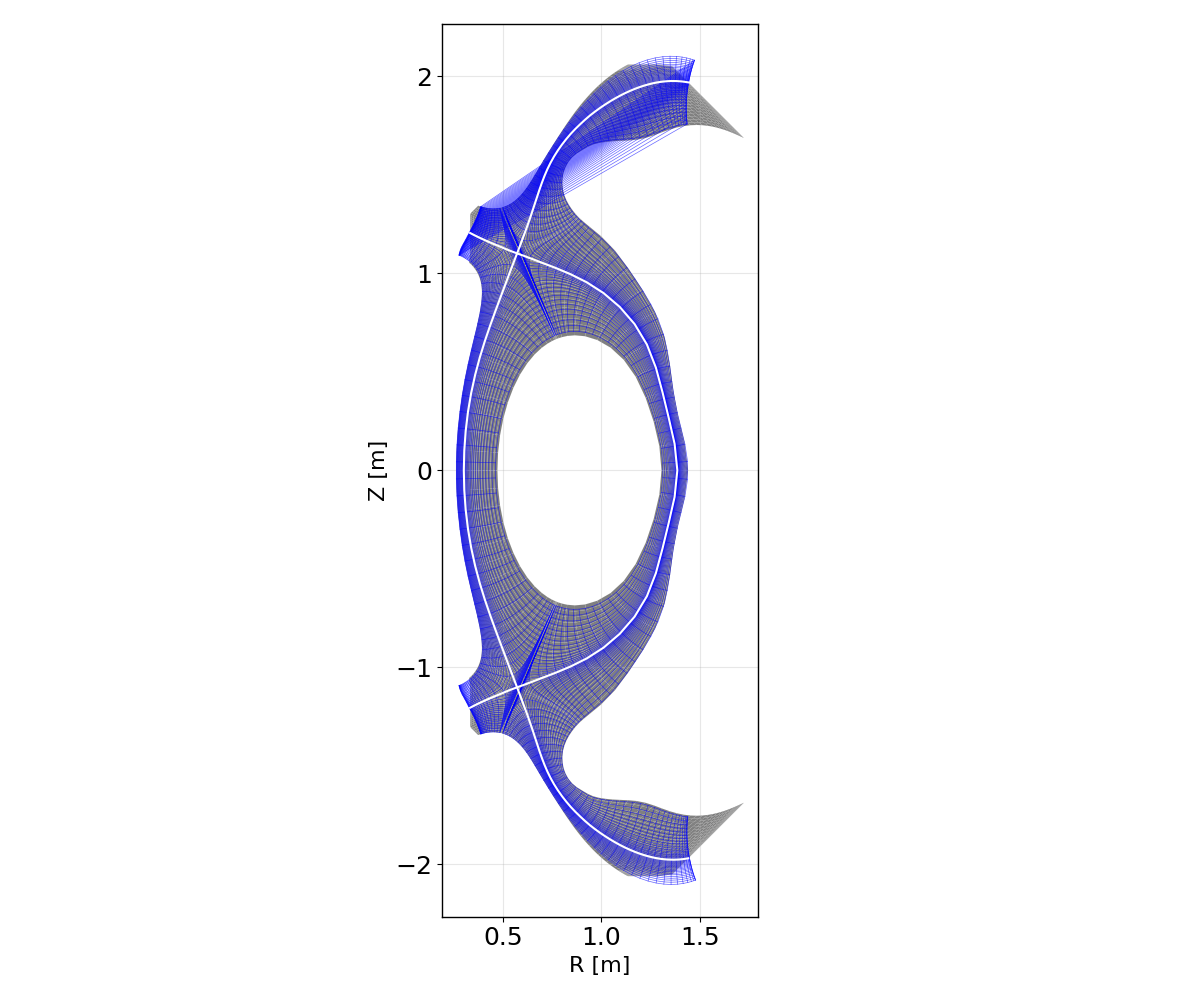

Grid dimensions: (38, 192)
Available variables: ['nx', 'ny', 'y_boundary_guards', 'curvature_type', 'Bt_axis', 'psi_axis', 'psi_bdry', 'psi_axis_gfile', 'psi_bdry_gfile', 'closed_wall_R', 'closed_wall_Z', 'Rxy', 'Rxy_xlow', 'Rxy_ylow', 'Zxy', 'Zxy_xlow', 'Zxy_ylow', 'psixy', 'psixy_xlow', 'psixy_ylow', 'dx', 'dx_xlow', 'dx_ylow', 'dy', 'dy_xlow', 'dy_ylow', 'poloidal_distance', 'poloidal_distance_xlow', 'poloidal_distance_ylow', 'parallel_distance', 'parallel_distance_xlow', 'parallel_distance_ylow', 'Brxy', 'Brxy_xlow', 'Brxy_ylow', 'Bzxy', 'Bzxy_xlow', 'Bzxy_ylow', 'Bpxy', 'Bpxy_xlow', 'Bpxy_ylow', 'Btxy', 'Btxy_xlow', 'Btxy_ylow', 'Bxy', 'Bxy_xlow', 'Bxy_ylow', 'hy', 'hy_xlow', 'hy_ylow', 'dphidy', 'dphidy_xlow', 'dphidy_ylow', 'ShiftTorsion', 'ShiftTorsion_xlow', 'ShiftTorsion_ylow', 'zShift', 'zShift_xlow', 'zShift_ylow', 'g11', 'g11_xlow', 'g11_ylow', 'g22', 'g22_xlow', 'g22_ylow', 'g33', 'g33_xlow', 'g33_ylow', 'g12', 'g12_xlow', 'g12_ylow', 'g13', 'g13_xlow', 'g13_ylow', 'g23',

In [5]:

%matplotlib widget
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Load the grid file
grid_file = "/Users/lloyd/Documents/hermes_dir/gridding/bout_2_.grd.nc"  # or .hdf5
ds = xr.open_dataset(grid_file)

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Get R and Z coordinates
# Grid files usually have Rxy and Zxy as 2D arrays [y, x] or [theta, psi]
R = ds['Rxy'].values
Z = ds['Zxy'].values

# Plot cell boundaries
# Plot horizontal lines (constant y/theta)
for i in range(R.shape[0]):
    ax.plot(R[i, :], Z[i, :], 'k-', linewidth=0.5, alpha=0.6, color = 'b')

# Plot vertical lines (constant x/radial)
for j in range(R.shape[1]):
    ax.plot(R[:, j], Z[:, j], 'k-', linewidth=0.5, alpha=0.6, color = 'b')

# Optional: highlight the separatrix if available
if 'ixseps1' in ds.attrs:
    ixseps1 = ds.attrs['ixseps1']
    ax.plot(R[:, ixseps1], Z[:, ixseps1], 'r-', linewidth=2, label='Separatrix')


# label = ['Hermes', 'SOLPS']
case.plot_2d('R', ax = ax, grid_only = True)#, linewidth = 0.5)


ax.set_xlabel('R [m]')
ax.set_ylabel('Z [m]')

ax.set_aspect('equal')
# ax.legend(label)
ax.grid(False, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Grid dimensions: {R.shape}")
print(f"Available variables: {list(ds.data_vars)}")

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def read_b2fgmtry(filename):
    """Read SOLPS b2fgmtry geometry file"""
    with open(filename, 'r') as f:
        # Read header
        line = f.readline().split()
        nx = int(line[0])  # radial cells
        ny = int(line[1])  # poloidal cells
        
        # Read grid coordinates
        # crx, cry are corner coordinates [ny, nx, 4]
        crx = np.zeros((ny, nx, 4))
        cry = np.zeros((ny, nx, 4))
        
        for iy in range(ny):
            for ix in range(nx):
                line = f.readline().split()
                for ic in range(4):
                    crx[iy, ix, ic] = float(line[ic*2])
                    cry[iy, ix, ic] = float(line[ic*2 + 1])
    
    return crx, cry, nx, ny

# Load grid
crx, cry, nx, ny = read_b2fgmtry("/Users/lloyd/Documents/solps/puff=13.0e21_pump=0.001_divchiconstfix_bcmom2_visper1_rxf0p1_parmvsa2_redoutpfrtrans_pufflfs_pin1.0/b2fgmtry")

fig, ax = plt.subplots(figsize=(12, 10))

# Plot all cells
for iy in range(ny):
    for ix in range(nx):
        corners = list(zip(crx[iy, ix, :], cry[iy, ix, :]))
        poly = patches.Polygon(corners, fill=False, edgecolor='black', 
                              linewidth=0.5, alpha=0.6)
        ax.add_patch(poly)

# Highlight separatrix if you know where it is
# For example, if separatrix is at ix = ix_sep
# ix_sep = 20  # example
# for iy in range(ny):
#     corners = list(zip(crx[iy, ix_sep, :], cry[iy, ix_sep, :]))
#     poly = patches.Polygon(corners, fill=False, edgecolor='red', linewidth=2)
#     ax.add_patch(poly)

ax.set_xlabel('R [m]')
ax.set_ylabel('Z [m]')
ax.set_title(f'SOLPS Grid ({nx}×{ny} cells)')
ax.set_aspect('equal')
ax.autoscale_view()
plt.tight_layout()
plt.show()

print(f"Grid size: {nx} (radial) × {ny} (poloidal) = {nx*ny} cells")



FileNotFoundError: [Errno 2] No such file or directory: '/Users/lloyd/Documents/solps/puff=13.0e21_pump=0.001_divchiconstfix_bcmom2_visper1_rxf0p1_parmvsa2_redoutpfrtrans_pufflfs_pin1.0/b2fgmtry'